# Entrega final B4-T2: dos políticas de riesgo de crédito y auditoría XAI

- Higinio Paterna Ortiz
- Hugo Vinuesa Busson
- Javier Chulvi Bernad

Este notebook integra las dos soluciones seleccionadas en una entrega reproducible:

| Coste | Modelo | Criterio |
|:--|:--|:--|
| **1:1** | **LinearBandits** | Política simétrica de Higinio; aprende el coste directamente como recompensa. |
| **1:10** | **LightGBM** | Solución asimétrica de Javi; estima riesgo y fija el umbral con predicciones out-of-fold. |

Para conservar **exactamente los resultados originales**, cada modelo mantiene su
protocolo de validación:

- LinearBandits usa el split 80/20 de Higinio tras eliminar age = 0.
- LightGBM usa el test del 15 % y el OOF repetido de Javi, sin eliminar esa fila.

Por tanto, sus métricas no se comparan como si procedieran del mismo test. La verificación
final comprueba la coincidencia fila a fila cuando los CSV originales están disponibles.

> Las explicaciones describen el comportamiento del modelo. No prueban causalidad ni
> garantizan que un cambio produzca la misma decisión crediticia real.

## 1. Entorno, librerías y reproducibilidad

In [1]:
%matplotlib inline
import itertools
import platform
import warnings
from importlib.metadata import version as package_version
from pathlib import Path

import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from space_bandits import LinearBandits
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
TARGET = "SeriousDlqin2yrs"
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

display(pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "seaborn": sns.__version__,
    "scikit-learn": sklearn.__version__,
    "LightGBM": lightgbm.__version__,
    "SHAP": shap.__version__,
    "space-bandits": package_version("space-bandits"),
}, name="Versión").to_frame())

,Versión
Python,3.12.9
NumPy,2.4.4
pandas,3.0.3
matplotlib,3.10.9
seaborn,0.13.2
scikit-learn,1.7.1
LightGBM,4.6.0
SHAP,0.52.0
space-bandits,0.0.993


## 2. Carga de datos y contrato de entrada

El notebook está pensado para ejecutarse desde la carpeta principal. Se comprueba que
construcción tiene etiquetas, producción no las tiene y ambos CSV comparten estructura.

In [2]:
candidatas = [Path.cwd(), Path.cwd().parent]
RUTA_BASE = next((p for p in candidatas if (p / "cs_construccion.csv").exists()), None)
assert RUTA_BASE is not None, "No se encuentra cs_construccion.csv."

ruta_construccion = RUTA_BASE / "cs_construccion.csv"
ruta_produccion = RUTA_BASE / "cs_produccion.csv"
ruta_diccionario = RUTA_BASE / "DataDictionary.csv"

construccion_original = pd.read_csv(ruta_construccion)
produccion = pd.read_csv(ruta_produccion)
diccionario = pd.read_csv(ruta_diccionario, sep=";").drop(
    columns=["Unnamed: 0"], errors="ignore"
)

assert construccion_original.columns.tolist() == produccion.columns.tolist()
assert construccion_original[TARGET].notna().all()
assert produccion[TARGET].isna().all()
assert set(construccion_original[TARGET].unique()) == {0, 1}

columnas_originales = construccion_original.columns.tolist()
variables_originales = [c for c in columnas_originales if c != TARGET]

display(pd.DataFrame({
    "Dataset": ["Construcción", "Producción"],
    "Filas": [len(construccion_original), len(produccion)],
    "Columnas": [construccion_original.shape[1], produccion.shape[1]],
    "% objetivo positivo": [100 * construccion_original[TARGET].mean(), np.nan],
}))
display(diccionario)

,Dataset,Filas,Columnas,% objetivo positivo
0,Construcción,105000,11,6.6838
1,Producción,45000,11,NaN


,Variable Name,Description,Type
0,SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
1,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
2,age,Age of borrower in years,integer
3,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
4,DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
5,MonthlyIncome,Monthly income,real
6,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
7,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
8,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer
9,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days past due but no worse in the last 2 years.,integer


## 3. Auditoría inicial y reproducción de las particiones originales

Se revisan desbalance, nulos y códigos especiales. A continuación se reconstruye cada
partición con la misma semilla y el mismo tratamiento usados en su notebook de origen.

,Comprobación,Construcción,Producción
0,Edad igual a 0,1,0
1,Utilización > 10,176,65
2,DebtRatio > 10,20171,8706
3,Algún contador de mora vale 96/98,188,81
4,MonthlyIncome ausente,20795,8936
5,NumberOfDependents ausente,2738,1186


,Protocolo,Partición,Filas,% positivos
0,Higinio,Train,83999,6.6834
1,Higinio,Test,21000,6.6857
2,Javi,Desarrollo,89250,6.6835
3,Javi,Test,15750,6.6857


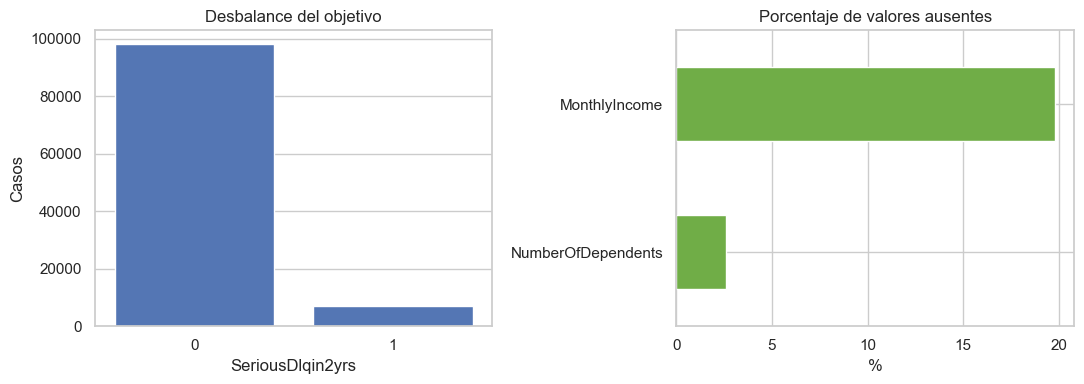

In [3]:
columnas_mora = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]

display(pd.DataFrame({
    "Comprobación": [
        "Edad igual a 0",
        "Utilización > 10",
        "DebtRatio > 10",
        "Algún contador de mora vale 96/98",
        "MonthlyIncome ausente",
        "NumberOfDependents ausente",
    ],
    "Construcción": [
        int((construccion_original["age"] == 0).sum()),
        int((construccion_original["RevolvingUtilizationOfUnsecuredLines"] > 10).sum()),
        int((construccion_original["DebtRatio"] > 10).sum()),
        int(construccion_original[columnas_mora].isin([96, 98]).any(axis=1).sum()),
        int(construccion_original["MonthlyIncome"].isna().sum()),
        int(construccion_original["NumberOfDependents"].isna().sum()),
    ],
    "Producción": [
        int((produccion["age"] == 0).sum()),
        int((produccion["RevolvingUtilizationOfUnsecuredLines"] > 10).sum()),
        int((produccion["DebtRatio"] > 10).sum()),
        int(produccion[columnas_mora].isin([96, 98]).any(axis=1).sum()),
        int(produccion["MonthlyIncome"].isna().sum()),
        int(produccion["NumberOfDependents"].isna().sum()),
    ],
}))

# Protocolo Higinio: elimina la única edad imposible y reserva 20 % para test.
construccion_higinio = construccion_original.loc[
    construccion_original["age"] > 0
].reset_index(drop=True)
X_higinio = construccion_higinio[variables_originales].copy()
y_higinio = construccion_higinio[TARGET].astype(int)
X_des_raw, X_test_raw, y_des, y_test = train_test_split(
    X_higinio,
    y_higinio,
    test_size=0.20,
    random_state=SEED,
    stratify=y_higinio,
)

# Protocolo Javi: conserva las 105.000 filas y reserva 15 % para test.
X_javi = construccion_original[variables_originales].copy()
y_javi = construccion_original[TARGET].astype(int)
indices_des_javi, indices_test_javi = train_test_split(
    construccion_original.index,
    test_size=0.15,
    random_state=SEED,
    stratify=y_javi,
)
display(pd.DataFrame({
    "Protocolo": ["Higinio", "Higinio", "Javi", "Javi"],
    "Partición": ["Train", "Test", "Desarrollo", "Test"],
    "Filas": [
        len(X_des_raw), len(X_test_raw),
        len(indices_des_javi), len(indices_test_javi),
    ],
    "% positivos": [
        100 * y_des.mean(), 100 * y_test.mean(),
        100 * y_javi.loc[indices_des_javi].mean(),
        100 * y_javi.loc[indices_test_javi].mean(),
    ],
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=y_javi, color="#4472C4", ax=axes[0])
axes[0].set_title("Desbalance del objetivo")
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel("Casos")
nulos = construccion_original[variables_originales].isna().mean().mul(100)
nulos[nulos > 0].sort_values().plot.barh(ax=axes[1], color="#70AD47")
axes[1].set_title("Porcentaje de valores ausentes")
axes[1].set_xlabel("%")
plt.tight_layout()
plt.show()

## 4. Función de coste y orientación FP/FN

La clase positiva es la mora grave. Un falso positivo rechaza a un cliente que habría
pagado; un falso negativo concede a un cliente que incurre en mora. En 1:10 el segundo
error cuesta diez veces más.

In [4]:
def costes_individuales(y_true, y_pred, coste_fp=1.0, coste_fn=1.0):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return (
        ((y_pred == 1) & (y_true == 0)).astype(float) * coste_fp
        + ((y_pred == 0) & (y_true == 1)).astype(float) * coste_fn
    )


def coste_medio(y_true, y_pred, coste_fp=1.0, coste_fn=1.0):
    return float(costes_individuales(y_true, y_pred, coste_fp, coste_fn).mean())


def optimizar_umbral(y_true, probabilidades, coste_fp=1.0, coste_fn=1.0):
    y_true = np.asarray(y_true, dtype=int)
    probabilidades = np.asarray(probabilidades, dtype=float)
    fpr, tpr, umbrales = roc_curve(y_true, probabilidades)
    n_negativos = (y_true == 0).sum()
    n_positivos = (y_true == 1).sum()
    costes = (
        fpr * n_negativos * coste_fp
        + (1 - tpr) * n_positivos * coste_fn
    ) / len(y_true)
    mejor = int(np.nanargmin(costes))
    return float(umbrales[mejor]), float(costes[mejor])


y_prueba = np.array([0, 0, 1, 1])
pred_prueba = np.array([0, 1, 0, 1])
assert costes_individuales(y_prueba, pred_prueba, 1, 10).tolist() == [0, 1, 10, 0]
print("Prueba de orientación FP/FN superada.")

Prueba de orientación FP/FN superada.


## 5. Modelo 1:1 — LinearBandits

Se conserva la lógica de Higinio. La limpieza aprende sus parámetros solo con desarrollo:
medianas por tramo de edad, percentil 95 de DebtRatio y máximos legítimos para sustituir
96/98. Después se escala y cada cliente aporta la recompensa de ambas acciones.

In [5]:
CORTES_EDAD = [0, 30, 40, 50, 60, 70, 150]


class LimpiadorBandit:
    def __init__(self, cortes=CORTES_EDAD, centinelas=(96, 98)):
        self.cortes = cortes
        self.centinelas = list(centinelas)
        self.cols_morosidad = columnas_mora

    def fit(self, X):
        tramo = pd.cut(X["age"], self.cortes)
        self.medianas_, self.mediana_global_ = {}, {}
        for col in ["MonthlyIncome", "NumberOfDependents"]:
            self.medianas_[col] = X.groupby(tramo, observed=True)[col].median()
            self.mediana_global_[col] = X[col].median()
        self.tope_debtratio_ = float(X["DebtRatio"].quantile(0.95))
        self.max_legit_ = {
            c: int(X.loc[~X[c].isin(self.centinelas), c].max())
            for c in self.cols_morosidad
        }
        return self

    def transform(self, X):
        X = X.copy()
        tramo = pd.cut(X["age"], self.cortes)
        for col in ["MonthlyIncome", "NumberOfDependents"]:
            X[f"{col}_missing"] = X[col].isna().astype("int8")
            relleno = tramo.map(self.medianas_[col].to_dict()).astype(float)
            X[col] = X[col].fillna(relleno).fillna(self.mediana_global_[col])
        X["RevolvingUtilizationOfUnsecuredLines"] = X[
            "RevolvingUtilizationOfUnsecuredLines"
        ].clip(upper=10)
        X["DebtRatio"] = X["DebtRatio"].clip(upper=self.tope_debtratio_)
        X["PastDue_centinela"] = (
            X[self.cols_morosidad].isin(self.centinelas).any(axis=1).astype("int8")
        )
        for col in self.cols_morosidad:
            X.loc[X[col].isin(self.centinelas), col] = self.max_legit_[col]
        return X


class BanditCosteSensible:
    def __init__(self, X_scaled, y_train, coste_fp, coste_fn):
        self.matriz_recompensa = np.array(
            [[0.0, -coste_fn], [-coste_fp, 0.0]], dtype=float
        )
        X_arr = np.asarray(X_scaled, dtype=float)
        y_arr = np.asarray(y_train, dtype=int)
        n = len(X_arr)
        self.model = LinearBandits(num_actions=2, num_features=X_arr.shape[1])
        # Mismo posterior batch que LinearBandits.fit, calculado con estadísticas
        # suficientes. Evita duplicar y almacenar 2*n contextos en el buffer de torch.
        X_intercepto = np.column_stack([X_arr, np.ones(n)])
        precision = (
            X_intercepto.T @ X_intercepto
            + self.model.lambda_prior * np.eye(X_intercepto.shape[1])
        )
        covarianza = np.linalg.inv(precision)
        for accion in [0, 1]:
            recompensas = self.matriz_recompensa[accion, y_arr]
            mu = covarianza @ (X_intercepto.T @ recompensas)
            self.model.precision[accion] = precision.copy()
            self.model.cov[accion] = covarianza.copy()
            self.model.mu[accion] = mu
            self.model.a[accion] = self.model.a0 + n / 2.0
            self.model.b[accion] = self.model.b0 + 0.5 * (
                recompensas.T @ recompensas - mu.T @ precision @ mu
            )
        self.model.t = 2 * n
        self.n_observaciones = 2 * n

    def predict(self, X_scaled):
        return np.asarray(
            self.model.predict(np.asarray(X_scaled), thompson=False)
        ).astype(int)

    def score_denegar(self, X_scaled):
        valores = self.model.expected_values(np.asarray(X_scaled))
        return np.asarray(valores[1] - valores[0])


limpiador_bandit = LimpiadorBandit().fit(X_des_raw)
X_band_des_limpio = limpiador_bandit.transform(X_des_raw)
X_band_test_limpio = limpiador_bandit.transform(X_test_raw)
assert not X_band_des_limpio.isna().any().any()
assert not X_band_test_limpio.isna().any().any()

scaler_bandit = StandardScaler().fit(X_band_des_limpio)
X_band_des_scaled = pd.DataFrame(
    scaler_bandit.transform(X_band_des_limpio),
    columns=X_band_des_limpio.columns,
    index=X_band_des_limpio.index,
)
X_band_test_scaled = pd.DataFrame(
    scaler_bandit.transform(X_band_test_limpio),
    columns=X_band_test_limpio.columns,
    index=X_band_test_limpio.index,
)

bandit_11 = BanditCosteSensible(X_band_des_scaled, y_des, 1, 1)
pred_test_bandit_11 = bandit_11.predict(X_band_test_scaled)
score_test_bandit_11 = bandit_11.score_denegar(X_band_test_scaled)
print(
    f"LinearBandits 1:1: {bandit_11.n_observaciones:,} observaciones, "
    f"{X_band_des_scaled.shape[1]} variables."
)

LinearBandits 1:1: 167,998 observaciones, 13 variables.


## 6. Modelo 1:10 — LightGBM con umbral OOF

Se conserva la arquitectura de Javi: 15 hojas, regularización y parada temprana. Cada
observación de desarrollo recibe tres probabilidades out-of-fold, procedentes de tres
repeticiones de cinco folds. El umbral 1:10 se fija sin consultar el test.

In [6]:
def preparar_lightgbm(datos):
    X = datos.copy()
    if TARGET in X.columns:
        X = X.drop(columns=TARGET)
    X["MonthlyIncome_missing"] = X["MonthlyIncome"].isna().astype("int8")
    X["NumberOfDependents_missing"] = X["NumberOfDependents"].isna().astype("int8")
    X["DelinquencySentinel96_98"] = (
        X[columnas_mora].isin([96, 98]).any(axis=1).astype("int8")
    )
    X[columnas_mora] = X[columnas_mora].mask(X[columnas_mora].isin([96, 98]))
    edad_invalida = (X["age"] <= 0) | (X["age"] > 110)
    X["age_invalid"] = edad_invalida.astype("int8")
    X["age"] = X["age"].mask(edad_invalida)
    return X


def crear_lightgbm(n_estimators=2_000, random_state=SEED):
    return LGBMClassifier(
        objective="binary",
        n_estimators=n_estimators,
        learning_rate=0.02,
        num_leaves=15,
        min_child_samples=200,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=2.0,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1,
    )

def crear_lightgbm_fijo(random_state=SEED):
    return LGBMClassifier(
        objective="binary",
        n_estimators=300,
        learning_rate=0.04,
        num_leaves=7,
        min_child_samples=200,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=random_state,
        n_jobs=-1,
        verbosity=-1,
    )

X_lgb_des_raw = X_javi.loc[indices_des_javi].copy()
X_lgb_test_raw = X_javi.loc[indices_test_javi].copy()
y_lgb_des = y_javi.loc[indices_des_javi].copy()
y_lgb_test = y_javi.loc[indices_test_javi].copy()
X_lgb_des = preparar_lightgbm(X_lgb_des_raw)
X_lgb_test = preparar_lightgbm(X_lgb_test_raw)
X_lgb_des_cv = X_lgb_des.reset_index(drop=True)
y_lgb_des_cv = y_lgb_des.reset_index(drop=True)

### 6.1 Comparación exploratoria de modelos

Se reconstruye el train/validación de Javi para comprobar que el modelo no lineal aporta
valor frente a una regresión logística y un árbol pequeño. Esta validación no consulta
el test final.

In [7]:
indices_train_exp, indices_val_exp = train_test_split(
    indices_des_javi,
    test_size=0.17647058823529413,
    random_state=SEED,
    stratify=y_javi.loc[indices_des_javi],
)
X_train_exp = preparar_lightgbm(X_javi.loc[indices_train_exp])
X_val_exp = preparar_lightgbm(X_javi.loc[indices_val_exp])
y_train_exp = y_javi.loc[indices_train_exp]
y_val_exp = y_javi.loc[indices_val_exp]

modelos_exploratorios = {
    "Regresión logística": Pipeline([
        ("imputación", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=2_000, random_state=SEED)),
    ]),
    "Árbol pequeño": Pipeline([
        ("imputación", SimpleImputer(strategy="median")),
        ("modelo", DecisionTreeClassifier(
            max_leaf_nodes=12, min_samples_leaf=200, random_state=SEED
        )),
    ]),
    "LightGBM conservador (7 hojas)": crear_lightgbm_fijo(),
}

filas_exploratorias = []
for nombre, modelo in modelos_exploratorios.items():
    modelo.fit(X_train_exp, y_train_exp)
    p_val = modelo.predict_proba(X_val_exp)[:, 1]
    _, coste_11_exp = optimizar_umbral(y_val_exp, p_val, 1, 1)
    _, coste_110_exp = optimizar_umbral(y_val_exp, p_val, 1, 10)
    filas_exploratorias.append({
        "Modelo": nombre,
        "ROC-AUC": roc_auc_score(y_val_exp, p_val),
        "PR-AUC": average_precision_score(y_val_exp, p_val),
        "Brier": brier_score_loss(y_val_exp, p_val),
        "Coste 1:1": coste_11_exp,
        "Coste 1:10": coste_110_exp,
    })
comparacion_exploratoria = pd.DataFrame(filas_exploratorias).sort_values(
    "Coste 1:10"
)
display(comparacion_exploratoria)

,Modelo,ROC-AUC,PR-AUC,Brier,Coste 1:1,Coste 1:10
2,LightGBM conservador (7 hojas),0.8736,0.4149,0.0484,0.0620,0.3148
1,Árbol pequeño,0.8329,0.3326,0.0503,0.0645,0.3472
0,Regresión logística,0.8303,0.3654,0.0522,0.0636,0.3548


### 6.2 Selección robusta con OOF

Se compara el LightGBM conservador de 7 hojas con el finalista de 15 hojas y parada
temprana. El primero usa cinco folds; el segundo promedia tres repeticiones de cinco
folds, como en el notebook original.

In [8]:
p_oof_l7 = np.zeros(len(X_lgb_des_cv), dtype=float)
cv_l7 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for fold, (idx_fit, idx_val) in enumerate(cv_l7.split(X_lgb_des_cv, y_lgb_des_cv)):
    modelo_l7 = crear_lightgbm_fijo(random_state=SEED + fold)
    modelo_l7.fit(X_lgb_des_cv.iloc[idx_fit], y_lgb_des_cv.iloc[idx_fit])
    p_oof_l7[idx_val] = modelo_l7.predict_proba(X_lgb_des_cv.iloc[idx_val])[:, 1]

suma_oof = np.zeros(len(X_lgb_des_cv), dtype=float)
conteo_oof = np.zeros(len(X_lgb_des_cv), dtype=int)
mejores_iteraciones = []

for repeticion in range(3):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + repeticion)
    for fold, (idx_fit, idx_val) in enumerate(cv.split(X_lgb_des_cv, y_lgb_des_cv)):
        modelo_fold = crear_lightgbm(
            n_estimators=2_000, random_state=SEED + 100 * repeticion + fold
        )
        modelo_fold.fit(
            X_lgb_des_cv.iloc[idx_fit],
            y_lgb_des_cv.iloc[idx_fit],
            eval_set=[(X_lgb_des_cv.iloc[idx_val], y_lgb_des_cv.iloc[idx_val])],
            eval_metric="binary_logloss",
            callbacks=[lightgbm.early_stopping(100, verbose=False)],
        )
        mejores_iteraciones.append(modelo_fold.best_iteration_)
        suma_oof[idx_val] += modelo_fold.predict_proba(
            X_lgb_des_cv.iloc[idx_val]
        )[:, 1]
        conteo_oof[idx_val] += 1

assert (conteo_oof == 3).all()
p_oof_lgb = suma_oof / conteo_oof
umbral_lgb_110, coste_oof_lgb_110 = optimizar_umbral(
    y_lgb_des_cv, p_oof_lgb, 1, 10
)

filas_comparacion_oof = []
for nombre, probabilidades in [
    ("LightGBM 7 hojas fijo", p_oof_l7),
    ("LightGBM 15 hojas + early stopping", p_oof_lgb),
]:
    umbral_11_candidato, coste_11_candidato = optimizar_umbral(
        y_lgb_des_cv, probabilidades, 1, 1
    )
    umbral_110_candidato, coste_110_candidato = optimizar_umbral(
        y_lgb_des_cv, probabilidades, 1, 10
    )
    filas_comparacion_oof.append({
        "Modelo": nombre,
        "ROC-AUC OOF": roc_auc_score(y_lgb_des_cv, probabilidades),
        "PR-AUC OOF": average_precision_score(y_lgb_des_cv, probabilidades),
        "Brier OOF": brier_score_loss(y_lgb_des_cv, probabilidades),
        "Umbral OOF 1:1": umbral_11_candidato,
        "Coste OOF 1:1": coste_11_candidato,
        "Umbral OOF 1:10": umbral_110_candidato,
        "Coste OOF 1:10": coste_110_candidato,
    })
comparacion_oof = pd.DataFrame(filas_comparacion_oof).sort_values(
    ["Coste OOF 1:10", "Coste OOF 1:1"]
)
assert comparacion_oof.iloc[0]["Modelo"] == "LightGBM 15 hojas + early stopping"

n_estimators_lgb = int(np.median(mejores_iteraciones))
modelo_lgb_110 = crear_lightgbm(n_estimators_lgb, SEED)
modelo_lgb_110.fit(X_lgb_des, y_lgb_des)
p_test_lgb_110 = modelo_lgb_110.predict_proba(X_lgb_test)[:, 1]
pred_test_lgb_110 = (p_test_lgb_110 >= umbral_lgb_110).astype(int)

display(comparacion_oof)
display(pd.DataFrame({
    "Umbral OOF 1:10 elegido": [umbral_lgb_110],
    "Coste OOF 1:10": [coste_oof_lgb_110],
    "Árboles finales": [n_estimators_lgb],
    "Ajustes OOF": [len(mejores_iteraciones)],
}, index=["LightGBM 1:10"]))

,Modelo,ROC-AUC OOF,PR-AUC OOF,Brier OOF,Umbral OOF 1:1,Coste OOF 1:1,Umbral OOF 1:10,Coste OOF 1:10
1,LightGBM 15 hojas + early stopping,0.8655,0.4046,0.0488,0.5380,0.0617,0.0907,0.3314
0,LightGBM 7 hojas fijo,0.8648,0.4043,0.0488,0.5447,0.0619,0.0885,0.3322


,Umbral OOF 1:10 elegido,Coste OOF 1:10,Árboles finales,Ajustes OOF
LightGBM 1:10,0.0907,0.3314,418,15


### 6.3 Calibración y curvas de coste OOF

Si las probabilidades estuvieran perfectamente calibradas, el umbral teórico 1:10 sería
1/11. Se contrasta con el mínimo OOF observado y se muestra cómo cambia el coste al mover
el umbral. El test sigue completamente aislado.

,Escenario,Umbral teórico,Umbral OOF,Coste OOF,Brier OOF
0,1:1,0.5000,0.5380,0.0617,0.0488
1,1:10,0.0909,0.0907,0.3314,0.0488


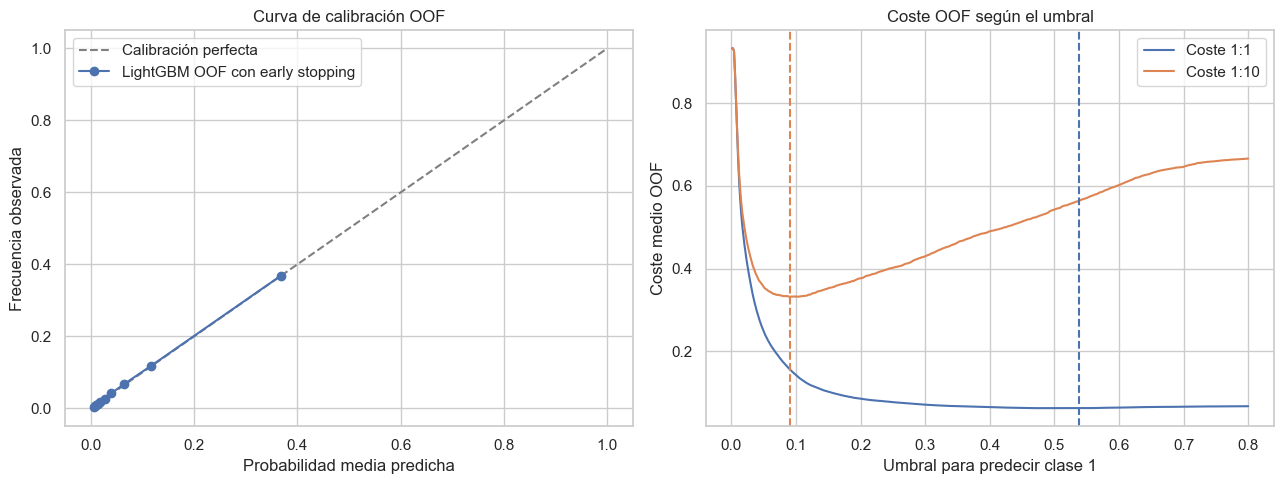

In [9]:
fraccion_positivos, media_predicha = calibration_curve(
    y_lgb_des_cv, p_oof_lgb, n_bins=10, strategy="quantile"
)
umbrales_grafico = np.linspace(0.001, 0.80, 500)
costes_11_grafico = [
    coste_medio(y_lgb_des_cv, p_oof_lgb >= u, 1, 1)
    for u in umbrales_grafico
]
costes_110_grafico = [
    coste_medio(y_lgb_des_cv, p_oof_lgb >= u, 1, 10)
    for u in umbrales_grafico
]
umbral_lgb_11, coste_oof_lgb_11 = optimizar_umbral(
    y_lgb_des_cv, p_oof_lgb, 1, 1
)
display(pd.DataFrame({
    "Escenario": ["1:1", "1:10"],
    "Umbral teórico": [0.5, 1 / 11],
    "Umbral OOF": [umbral_lgb_11, umbral_lgb_110],
    "Coste OOF": [coste_oof_lgb_11, coste_oof_lgb_110],
    "Brier OOF": [
        brier_score_loss(y_lgb_des_cv, p_oof_lgb),
        brier_score_loss(y_lgb_des_cv, p_oof_lgb),
    ],
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Calibración perfecta")
axes[0].plot(
    media_predicha, fraccion_positivos, "o-",
    label="LightGBM OOF con early stopping"
)
axes[0].set_xlabel("Probabilidad media predicha")
axes[0].set_ylabel("Frecuencia observada")
axes[0].set_title("Curva de calibración OOF")
axes[0].legend()

axes[1].plot(umbrales_grafico, costes_11_grafico, label="Coste 1:1")
axes[1].plot(umbrales_grafico, costes_110_grafico, label="Coste 1:10")
axes[1].axvline(umbral_lgb_11, color="C0", linestyle="--")
axes[1].axvline(umbral_lgb_110, color="C1", linestyle="--")
axes[1].set_xlabel("Umbral para predecir clase 1")
axes[1].set_ylabel("Coste medio OOF")
axes[1].set_title("Coste OOF según el umbral")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Evaluación final según cada protocolo original

Cada política se mide en el test intacto de su notebook original y se compara con
conceder a todos. Los costes no deben compararse entre sí como si fueran el mismo
experimento: cambian tanto la matriz de coste como las filas del test.

,Coste,Coste medio test,Baseline conceder a todos,ROC-AUC,PR-AUC,Sensibilidad,Precisión,F1,% riesgo/denegación,TN,FP,FN,TP
Política,,,,,,,,,,,,,
LinearBandits,1:1,0.0637,0.0669,0.8541,0.3697,0.1275,0.6130,0.2111,1.3905,19483,113,1225,179
LightGBM,1:10,0.3224,0.6686,0.8720,0.4027,0.7236,0.2601,0.3826,18.6032,12529,2168,291,762


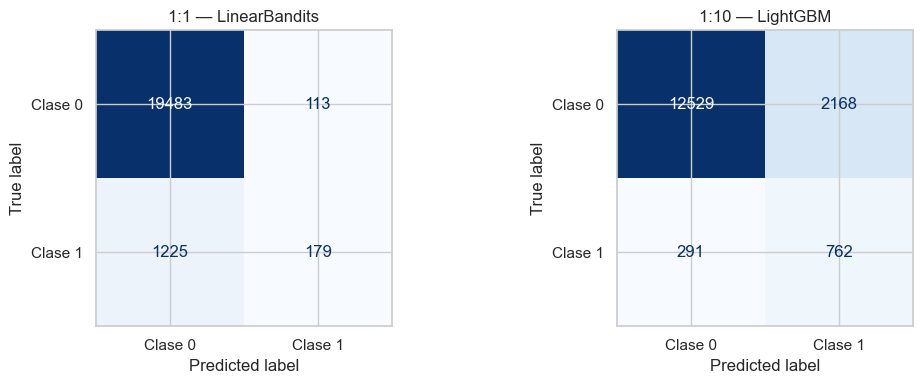

In [10]:
def resumen_metricas(nombre, y_true, pred, coste_fp, coste_fn, score):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "Política": nombre,
        "Coste": f"{int(coste_fp)}:{int(coste_fn)}",
        "Coste medio test": coste_medio(y_true, pred, coste_fp, coste_fn),
        "Baseline conceder a todos": coste_fn * np.mean(y_true),
        "ROC-AUC": roc_auc_score(y_true, score),
        "PR-AUC": average_precision_score(y_true, score),
        "Sensibilidad": recall_score(y_true, pred, zero_division=0),
        "Precisión": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "% riesgo/denegación": 100 * np.mean(pred),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }


resultados_test = pd.DataFrame([
    resumen_metricas(
        "LinearBandits", y_test, pred_test_bandit_11, 1, 1, score_test_bandit_11
    ),
    resumen_metricas(
        "LightGBM", y_lgb_test, pred_test_lgb_110, 1, 10, p_test_lgb_110
    ),
]).set_index("Política")

assert resultados_test.loc["LinearBandits", "Coste medio test"] < (
    resultados_test.loc["LinearBandits", "Baseline conceder a todos"]
)
assert resultados_test.loc["LightGBM", "Coste medio test"] < (
    resultados_test.loc["LightGBM", "Baseline conceder a todos"]
)
display(resultados_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, titulo, y_grafico, pred in [
    (axes[0], "1:1 — LinearBandits", y_test, pred_test_bandit_11),
    (axes[1], "1:10 — LightGBM", y_lgb_test, pred_test_lgb_110),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_grafico, pred, labels=[0, 1], display_labels=["Clase 0", "Clase 1"],
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

In [11]:
fila_bandit = resultados_test.loc["LinearBandits"]
fila_lgb = resultados_test.loc["LightGBM"]
display(Markdown(f"""
**Lectura de los tests originales.** En 1:1, LinearBandits reduce el coste medio de
**{fila_bandit['Baseline conceder a todos']:.4f}** a
**{fila_bandit['Coste medio test']:.4f}** y deniega el
**{fila_bandit['% riesgo/denegación']:.2f} %**. En 1:10, LightGBM reduce el baseline
de **{fila_lgb['Baseline conceder a todos']:.4f}** a
**{fila_lgb['Coste medio test']:.4f}**, con sensibilidad
**{fila_lgb['Sensibilidad']:.2%}** y una tasa de riesgo alto del
**{fila_lgb['% riesgo/denegación']:.2f} %**.
"""))


**Lectura de los tests originales.** En 1:1, LinearBandits reduce el coste medio de
**0.0669** a
**0.0637** y deniega el
**1.39 %**. En 1:10, LightGBM reduce el baseline
de **0.6686** a
**0.3224**, con sensibilidad
**72.36%** y una tasa de riesgo alto del
**18.60 %**.


## 8. Modelos de producción y verificación frente a los originales

Se reproduce la decisión de cada notebook fuente:

- Higinio aplica a producción el LinearBandits ya ajustado con su train del 80 %.
- Javi repite el OOF de 15 ajustes sobre las 105.000 filas, obtiene el umbral y número
  de árboles de producción, y reentrena LightGBM con todo construcción.

Si los CSV originales están presentes, se comparan las 45.000 predicciones fila a fila.
Esta comprobación es opcional: el notebook también funciona como entrega independiente.

In [12]:
X_prod_raw = produccion[variables_originales].copy()

# Producción 1:1: reutiliza exactamente el limpiador, scaler y bandit de Higinio.
X_band_prod_limpio = limpiador_bandit.transform(X_prod_raw)
X_band_prod_scaled = pd.DataFrame(
    scaler_bandit.transform(X_band_prod_limpio),
    columns=X_band_prod_limpio.columns,
)
pred_prod_11 = bandit_11.predict(X_band_prod_scaled)

# Producción 1:10: OOF completo y reentrenamiento final de Javi.
X_lgb_full = preparar_lightgbm(X_javi)
X_lgb_prod = preparar_lightgbm(X_prod_raw)
y_lgb_full = y_javi.reset_index(drop=True)
X_lgb_full_cv = X_lgb_full.reset_index(drop=True)
suma_oof_produccion = np.zeros(len(X_lgb_full_cv), dtype=float)
conteo_oof_produccion = np.zeros(len(X_lgb_full_cv), dtype=int)
iteraciones_produccion = []

for repeticion in range(3):
    cv_produccion = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=SEED + repeticion
    )
    for fold, (idx_fit, idx_val) in enumerate(
        cv_produccion.split(X_lgb_full_cv, y_lgb_full)
    ):
        modelo_fold = crear_lightgbm(
            n_estimators=2_000,
            random_state=SEED + 100 * repeticion + fold,
        )
        modelo_fold.fit(
            X_lgb_full_cv.iloc[idx_fit],
            y_lgb_full.iloc[idx_fit],
            eval_set=[(X_lgb_full_cv.iloc[idx_val], y_lgb_full.iloc[idx_val])],
            eval_metric="binary_logloss",
            callbacks=[lightgbm.early_stopping(100, verbose=False)],
        )
        iteraciones_produccion.append(modelo_fold.best_iteration_)
        suma_oof_produccion[idx_val] += modelo_fold.predict_proba(
            X_lgb_full_cv.iloc[idx_val]
        )[:, 1]
        conteo_oof_produccion[idx_val] += 1

assert (conteo_oof_produccion == 3).all()
p_oof_produccion = suma_oof_produccion / conteo_oof_produccion
umbral_lgb_110_produccion, coste_oof_lgb_110_produccion = optimizar_umbral(
    y_lgb_full, p_oof_produccion, 1, 10
)
n_estimators_lgb_produccion = int(np.median(iteraciones_produccion))
modelo_lgb_110_final = crear_lightgbm(n_estimators_lgb_produccion, SEED)
modelo_lgb_110_final.fit(X_lgb_full, y_javi)
p_prod_110 = modelo_lgb_110_final.predict_proba(X_lgb_prod)[:, 1]
pred_prod_110 = (p_prod_110 >= umbral_lgb_110_produccion).astype(int)

salida_11 = produccion.copy()
salida_110 = produccion.copy()
salida_11[TARGET] = pd.Series(pred_prod_11, index=salida_11.index, dtype="int64")
salida_110[TARGET] = pd.Series(pred_prod_110, index=salida_110.index, dtype="int64")
ruta_salida_11 = RUTA_BASE / "cs_produccion1.csv"
ruta_salida_110 = RUTA_BASE / "cs_produccion2.csv"
salida_11.to_csv(ruta_salida_11, index=False)
salida_110.to_csv(ruta_salida_110, index=False)

for salida in [salida_11, salida_110]:
    assert salida.shape == produccion.shape == (45_000, 11)
    assert salida.columns.tolist() == columnas_originales
    assert salida[TARGET].isna().sum() == 0
    assert set(salida[TARGET].unique()).issubset({0, 1})
    pd.testing.assert_frame_equal(
        salida[variables_originales], produccion[variables_originales]
    )

# Verificación opcional: igualdad fila a fila con las entregas originales.
rutas_referencia = [
    RUTA_BASE / "higinio/cs_produccion1.csv",
    RUTA_BASE / "javi/cs_produccion2.csv",
]
salidas_generadas = [salida_11, salida_110]
estados_referencia = []
diferencias_referencia = []
for ruta_referencia, salida_generada in zip(
    rutas_referencia, salidas_generadas
):
    if ruta_referencia.exists():
        referencia = pd.read_csv(ruta_referencia)
        diferencias = int(
            (salida_generada[TARGET].to_numpy() != referencia[TARGET].to_numpy()).sum()
        )
        assert diferencias == 0
        estados_referencia.append("Coincidencia exacta")
        diferencias_referencia.append(diferencias)
    else:
        estados_referencia.append("Referencia no disponible")
        diferencias_referencia.append(np.nan)

resumen_produccion = pd.DataFrame({
    "Formato": ["1:1", "1:10"],
    "Modelo": ["LinearBandits", "LightGBM"],
    "Fichero": [ruta_salida_11.name, ruta_salida_110.name],
    "Filas": [len(salida_11), len(salida_110)],
    "Predicciones clase 1": [int(pred_prod_11.sum()), int(pred_prod_110.sum())],
    "% clase 1": [100 * pred_prod_11.mean(), 100 * pred_prod_110.mean()],
    "Verificación opcional": estados_referencia,
    "Filas distintas vs. original": diferencias_referencia,
})
display(resumen_produccion)
display(pd.DataFrame({
    "Magnitud LightGBM producción": [
        "Umbral OOF 1:10", "Coste OOF 1:10", "Árboles finales", "Ajustes OOF"
    ],
    "Valor": [
        umbral_lgb_110_produccion,
        coste_oof_lgb_110_produccion,
        n_estimators_lgb_produccion,
        len(iteraciones_produccion),
    ],
}))

,Formato,Modelo,Fichero,Filas,Predicciones clase 1,% clase 1,Verificación opcional,Filas distintas vs. original
0,1:1,LinearBandits,cs_produccion1.csv,45000,658,1.4622,Coincidencia exacta,0
1,1:10,LightGBM,cs_produccion2.csv,45000,9157,20.3489,Coincidencia exacta,0


,Magnitud LightGBM producción,Valor
0,Umbral OOF 1:10,0.0815
1,Coste OOF 1:10,0.3296
2,Árboles finales,455.0000
3,Ajustes OOF,15.0000


## 9. SHAP global: qué gobierna cada política

Esta vista global explica las **políticas finalmente entregadas**:

- LinearBandits 1:1 reutiliza el mismo modelo en evaluación y producción.
- LightGBM 1:10 usa el modelo final de 455 árboles, entrenado con las 105.000 filas,
  y una muestra de producción.

Para LinearBandits se explica el margen a favor de denegar; para LightGBM, la
probabilidad de mora. Las escalas son diferentes: se comparan rankings, no magnitudes.

,Variable,Media |SHAP|,Modelo
6,NumberOfTimes90DaysLate,0.0561,LinearBandits 1:1
2,NumberOfTime30-59DaysPastDueNotWorse,0.0500,LinearBandits 1:1
0,RevolvingUtilizationOfUnsecuredLines,0.0304,LinearBandits 1:1
8,NumberOfTime60-89DaysPastDueNotWorse,0.0261,LinearBandits 1:1
1,age,0.0224,LinearBandits 1:1
12,PastDue_centinela,0.0188,LinearBandits 1:1
3,DebtRatio,0.0085,LinearBandits 1:1
10,MonthlyIncome_missing,0.0076,LinearBandits 1:1
7,NumberRealEstateLoansOrLines,0.0058,LinearBandits 1:1
9,NumberOfDependents,0.0037,LinearBandits 1:1


,Variable,Media |SHAP|,Modelo
0,RevolvingUtilizationOfUnsecuredLines,0.0315,LightGBM 1:10 final de producción
6,NumberOfTimes90DaysLate,0.0283,LightGBM 1:10 final de producción
2,NumberOfTime30-59DaysPastDueNotWorse,0.0199,LightGBM 1:10 final de producción
8,NumberOfTime60-89DaysPastDueNotWorse,0.0133,LightGBM 1:10 final de producción
1,age,0.0095,LightGBM 1:10 final de producción
5,NumberOfOpenCreditLinesAndLoans,0.0069,LightGBM 1:10 final de producción
3,DebtRatio,0.0058,LightGBM 1:10 final de producción
4,MonthlyIncome,0.0045,LightGBM 1:10 final de producción
7,NumberRealEstateLoansOrLines,0.0036,LightGBM 1:10 final de producción
9,NumberOfDependents,0.0014,LightGBM 1:10 final de producción


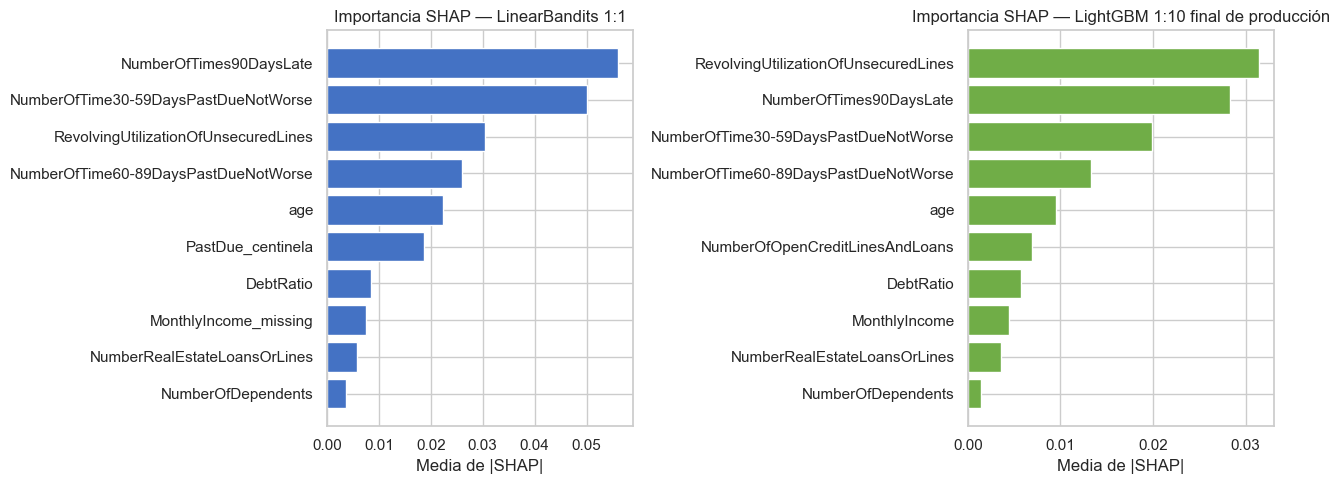

In [13]:
fondo_bandit = shap.sample(X_band_des_scaled, 80, random_state=SEED)
X_shap_bandit = X_band_test_scaled.sample(300, random_state=SEED)
explicador_bandit = shap.Explainer(
    bandit_11.score_denegar, fondo_bandit, algorithm="permutation"
)
shap_bandit = explicador_bandit(X_shap_bandit)

fondo_lgb_final = X_lgb_full.sample(100, random_state=SEED)
X_shap_lgb_final = X_lgb_prod.sample(800, random_state=SEED)
explicador_lgb_final = shap.TreeExplainer(
    modelo_lgb_110_final,
    data=fondo_lgb_final,
    feature_perturbation="interventional",
    model_output="probability",
)
shap_lgb_final = explicador_lgb_final(
    X_shap_lgb_final, check_additivity=False
)

importancia_bandit = pd.DataFrame({
    "Variable": X_shap_bandit.columns,
    "Media |SHAP|": np.abs(shap_bandit.values).mean(axis=0),
    "Modelo": "LinearBandits 1:1",
}).sort_values("Media |SHAP|", ascending=False)
importancia_lgb_final = pd.DataFrame({
    "Variable": X_shap_lgb_final.columns,
    "Media |SHAP|": np.abs(shap_lgb_final.values).mean(axis=0),
    "Modelo": "LightGBM 1:10 final de producción",
}).sort_values("Media |SHAP|", ascending=False)
display(importancia_bandit.head(10))
display(importancia_lgb_final.head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tabla, titulo, color in [
    (axes[0], importancia_bandit.head(10), "LinearBandits 1:1", "#4472C4"),
    (
        axes[1],
        importancia_lgb_final.head(10),
        "LightGBM 1:10 final de producción",
        "#70AD47",
    ),
]:
    orden = tabla.sort_values("Media |SHAP|")
    ax.barh(orden["Variable"], orden["Media |SHAP|"], color=color)
    ax.set_title(f"Importancia SHAP — {titulo}")
    ax.set_xlabel("Media de |SHAP|")
plt.tight_layout()
plt.show()

### 9.1 Importancia por permutación orientada al coste

Esta auditoría explica el **modelo de evaluación** de 418 árboles y su umbral 0,0907,
porque necesita etiquetas del test intacto. Se permuta cada variable y se mide cuánto
aumenta el coste 1:10. El modelo y el umbral permanecen fijos.

,Variable,Aumento medio de coste,Desviación
0,RevolvingUtilizationOfUnsecuredLines,0.0707,0.0017
1,NumberOfTimes90DaysLate,0.0562,0.0013
2,NumberOfTime30-59DaysPastDueNotWorse,0.0465,0.0007
3,NumberOfTime60-89DaysPastDueNotWorse,0.0344,0.0023
4,age,0.0161,0.0022
5,NumberOfOpenCreditLinesAndLoans,0.0153,0.0014
6,DebtRatio,0.0140,0.0022
7,NumberRealEstateLoansOrLines,0.0067,0.0036
8,MonthlyIncome,0.0064,0.0017
9,NumberOfDependents,0.0018,0.0009


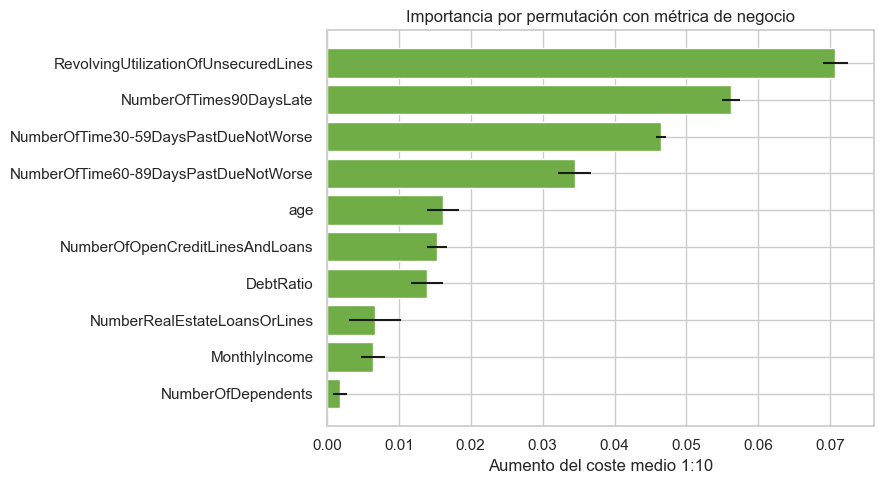

In [14]:
rng_permutacion = np.random.default_rng(SEED)
coste_base_permutacion = coste_medio(
    y_lgb_test, pred_test_lgb_110, 1, 10
)
filas_permutacion = []
for columna in X_lgb_test.columns:
    incrementos = []
    for _ in range(4):
        X_permutado = X_lgb_test.copy()
        X_permutado[columna] = rng_permutacion.permutation(
            X_permutado[columna].to_numpy()
        )
        p_permutado = modelo_lgb_110.predict_proba(X_permutado)[:, 1]
        pred_permutado = (p_permutado >= umbral_lgb_110).astype(int)
        incrementos.append(
            coste_medio(y_lgb_test, pred_permutado, 1, 10)
            - coste_base_permutacion
        )
    filas_permutacion.append({
        "Variable": columna,
        "Aumento medio de coste": np.mean(incrementos),
        "Desviación": np.std(incrementos),
    })

importancia_permutacion = pd.DataFrame(filas_permutacion).sort_values(
    "Aumento medio de coste", ascending=False
).reset_index(drop=True)
display(importancia_permutacion)

top_perm = importancia_permutacion.head(10).sort_values("Aumento medio de coste")
plt.figure(figsize=(9, 5))
plt.barh(
    top_perm["Variable"],
    top_perm["Aumento medio de coste"],
    xerr=top_perm["Desviación"],
    color="#70AD47",
)
plt.xlabel("Aumento del coste medio 1:10")
plt.title("Importancia por permutación con métrica de negocio")
plt.tight_layout()
plt.show()

## 10. Explicaciones locales

Para LinearBandits se conserva un caso cercano a su frontera. Para LightGBM se estudian
explícitamente un TN, TP, FP y FN del test intacto, elegidos cerca del umbral 1:10. Los
casos denegados incluyen además una comunicación ilustrativa para el cliente.

**Modelo explicado en este apartado:** el LightGBM de evaluación, entrenado con el
conjunto de desarrollo (418 árboles) y aplicado con el umbral OOF 1:10 de 0,0907. De
este modo, las explicaciones locales se calculan sobre casos nunca vistos durante el
entrenamiento. El SHAP global anterior, en cambio, explica el modelo final de producción.

LinearBandits — score: +0.0002; clase real: 0


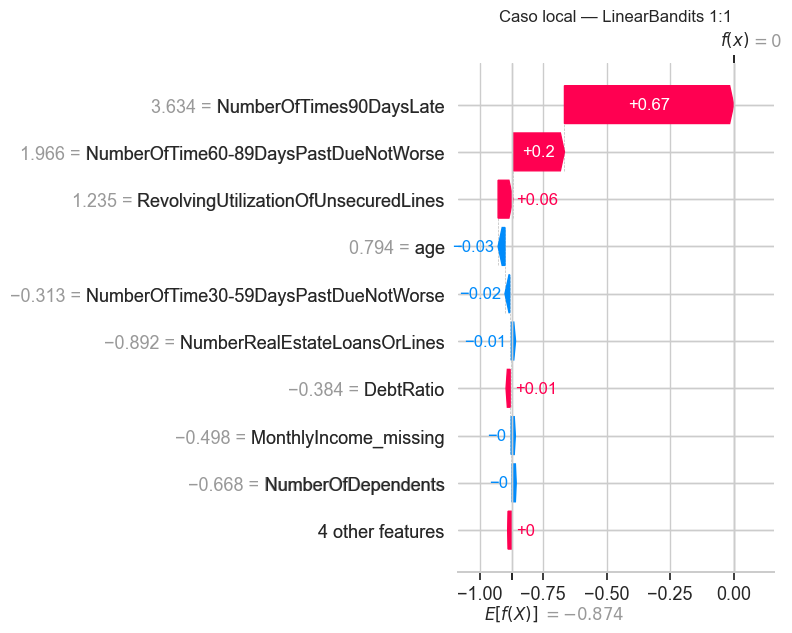

,Caso,Índice original,Clase real,Probabilidad,Umbral 1:10,Predicción
0,TN — sano concedido,20118,0,0.0907,0.0907,0
1,TP — moroso denegado,66854,1,0.0909,0.0907,1
2,FP — sano denegado,60989,0,0.0908,0.0907,1
3,FN — moroso concedido,13793,1,0.0902,0.0907,0


,Caso,Variable,Valor,SHAP,Dirección
0,TN — sano concedido,RevolvingUtilizationOfUnsecuredLines,1.0000,0.0548,sube riesgo
1,TN — sano concedido,age,38.0000,0.0177,sube riesgo
2,TN — sano concedido,NumberOfTimes90DaysLate,0.0000,-0.0159,baja riesgo
3,TP — moroso denegado,NumberOfTime30-59DaysPastDueNotWorse,3.0000,0.0956,sube riesgo
4,TP — moroso denegado,RevolvingUtilizationOfUnsecuredLines,0.0066,-0.0467,baja riesgo
5,TP — moroso denegado,NumberOfTimes90DaysLate,0.0000,-0.0154,baja riesgo
6,FP — sano denegado,NumberOfTime30-59DaysPastDueNotWorse,2.0000,0.0614,sube riesgo
7,FP — sano denegado,NumberOfOpenCreditLinesAndLoans,19.0000,0.0150,sube riesgo
8,FP — sano denegado,MonthlyIncome,"12,990.0000",-0.0149,baja riesgo
9,FN — moroso concedido,RevolvingUtilizationOfUnsecuredLines,0.8725,0.0502,sube riesgo


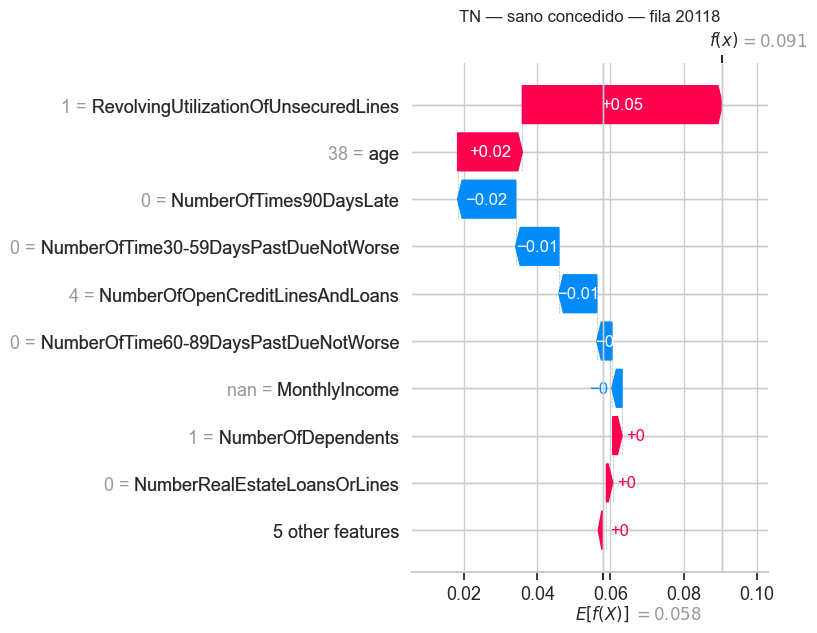

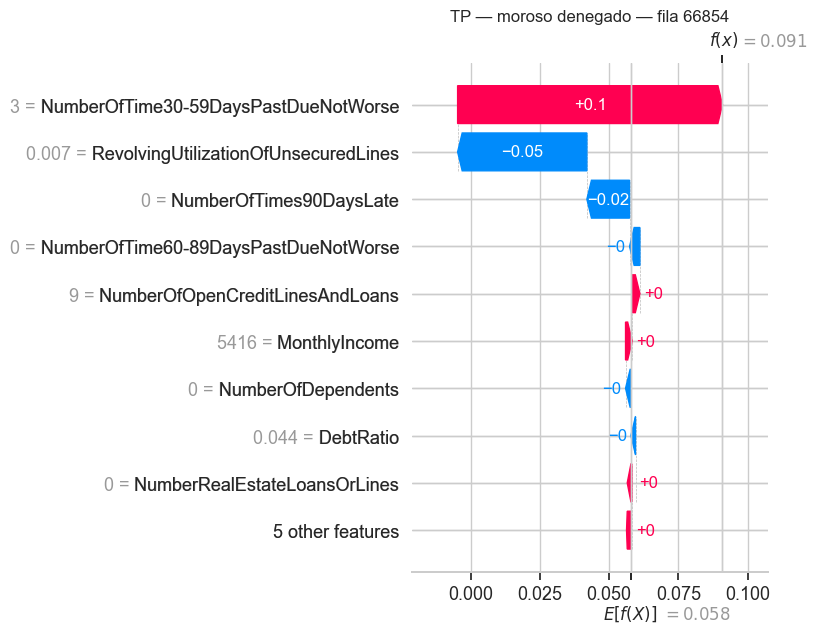

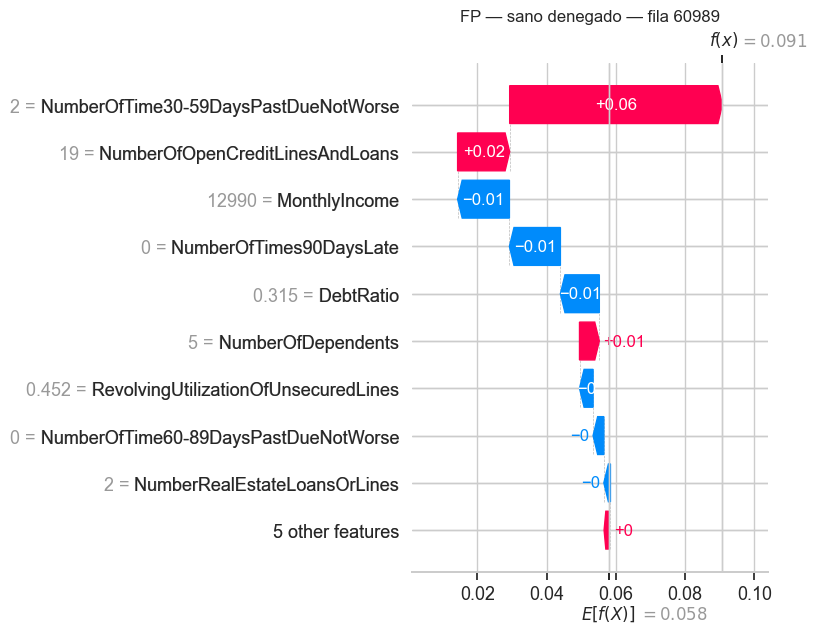

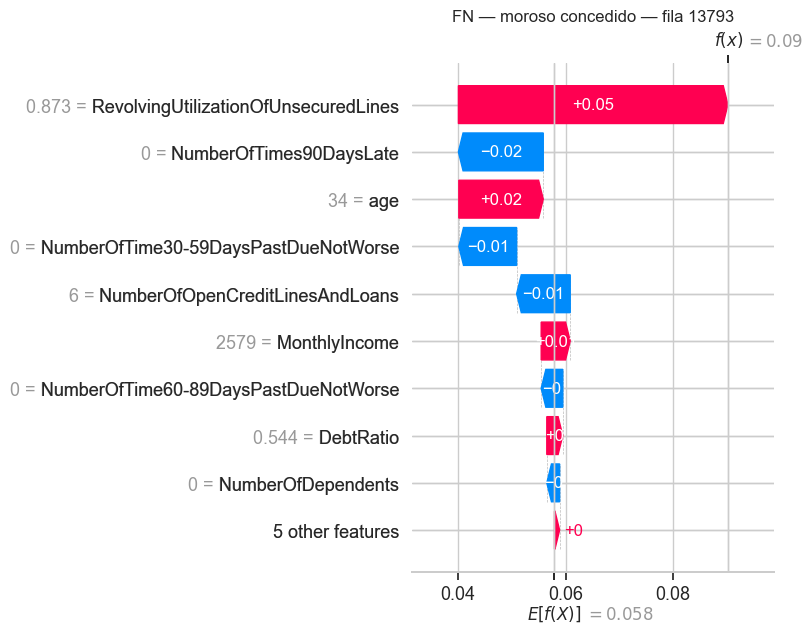


### Comunicación ilustrativa — solicitud 66854

La solicitud ha sido clasificada como riesgo alto bajo la política 1:10. El modelo estimó
una probabilidad de mora grave de **9.09%**, superior al
umbral aplicado de **9.07%**. Los factores que más elevaron la puntuación
fueron **retrasos de 30 a 59 días**, **número de préstamos y líneas abiertas**, **ingresos mensuales declarados**.

Estas contribuciones explican la decisión del modelo, pero no demuestran causalidad. Puede
solicitar una **revisión humana** y la **corrección de datos incompletos o incorrectos**.


---


### Comunicación ilustrativa — solicitud 60989

La solicitud ha sido clasificada como riesgo alto bajo la política 1:10. El modelo estimó
una probabilidad de mora grave de **9.08%**, superior al
umbral aplicado de **9.07%**. Los factores que más elevaron la puntuación
fueron **retrasos de 30 a 59 días**, **número de préstamos y líneas abiertas**, **personas dependientes**.

Estas contribuciones explican la decisión del modelo, pero no demuestran causalidad. Puede
solicitar una **revisión humana** y la **corrección de datos incompletos o incorrectos**.


In [15]:
pos_bandit_denegados = np.flatnonzero(pred_test_bandit_11 == 1)
pos_lgb_denegados = np.flatnonzero(pred_test_lgb_110 == 1)
assert len(pos_bandit_denegados) and len(pos_lgb_denegados)

i_bandit_local = int(pos_bandit_denegados[
    np.argmin(score_test_bandit_11[pos_bandit_denegados])
])
shap_bandit_local = explicador_bandit(X_band_test_scaled.iloc[[i_bandit_local]])

print(
    f"LinearBandits — score: {score_test_bandit_11[i_bandit_local]:+.4f}; "
    f"clase real: {int(y_test.iloc[i_bandit_local])}"
)
shap.plots.waterfall(shap_bandit_local[0], max_display=10, show=False)
plt.title("Caso local — LinearBandits 1:1")
plt.tight_layout()
plt.show()

p_test_lgb_serie = pd.Series(
    p_test_lgb_110, index=X_lgb_test.index, name="Probabilidad"
)
pred_test_lgb_serie = pd.Series(
    pred_test_lgb_110, index=X_lgb_test.index, name="Predicción"
)
usados_locales = set()

def escoger_caso_local(mascara):
    candidatos = [
        indice for indice in p_test_lgb_serie.index[mascara]
        if indice not in usados_locales
    ]
    assert candidatos, "No hay candidatos para una categoría SHAP local."
    elegido = min(
        candidatos,
        key=lambda i: abs(p_test_lgb_serie.loc[i] - umbral_lgb_110),
    )
    usados_locales.add(elegido)
    return elegido


especificaciones_locales = [
    ("TN — sano concedido", (y_lgb_test == 0) & (pred_test_lgb_serie == 0)),
    ("TP — moroso denegado", (y_lgb_test == 1) & (pred_test_lgb_serie == 1)),
    ("FP — sano denegado", (y_lgb_test == 0) & (pred_test_lgb_serie == 1)),
    ("FN — moroso concedido", (y_lgb_test == 1) & (pred_test_lgb_serie == 0)),
]
casos_lgb_locales = [
    (etiqueta, escoger_caso_local(mascara))
    for etiqueta, mascara in especificaciones_locales
]
indices_lgb_locales = [indice for _, indice in casos_lgb_locales]
X_lgb_locales = X_lgb_test.loc[indices_lgb_locales]
fondo_lgb_evaluacion = X_lgb_des.sample(100, random_state=SEED)
explicador_lgb_evaluacion = shap.TreeExplainer(
    modelo_lgb_110,
    data=fondo_lgb_evaluacion,
    feature_perturbation="interventional",
    model_output="probability",
)
shap_lgb_locales = explicador_lgb_evaluacion(
    X_lgb_locales, check_additivity=False
)

tabla_casos_locales = []
contribuciones_locales = []
for posicion, (etiqueta, indice) in enumerate(casos_lgb_locales):
    valores = shap_lgb_locales.values[posicion]
    orden = np.argsort(np.abs(valores))[::-1][:3]
    tabla_casos_locales.append({
        "Caso": etiqueta,
        "Índice original": indice,
        "Clase real": int(y_lgb_test.loc[indice]),
        "Probabilidad": p_test_lgb_serie.loc[indice],
        "Umbral 1:10": umbral_lgb_110,
        "Predicción": int(pred_test_lgb_serie.loc[indice]),
    })
    for j in orden:
        contribuciones_locales.append({
            "Caso": etiqueta,
            "Variable": X_lgb_locales.columns[j],
            "Valor": X_lgb_locales.iloc[posicion, j],
            "SHAP": valores[j],
            "Dirección": "sube riesgo" if valores[j] > 0 else "baja riesgo",
        })

tabla_casos_locales = pd.DataFrame(tabla_casos_locales)
contribuciones_locales = pd.DataFrame(contribuciones_locales)
display(tabla_casos_locales)
display(contribuciones_locales)

for posicion, (etiqueta, indice) in enumerate(casos_lgb_locales):
    shap.plots.waterfall(
        shap_lgb_locales[posicion], max_display=10, show=False
    )
    plt.title(f"{etiqueta} — fila {indice}")
    plt.tight_layout()
    plt.show()

# Comunicación para los dos casos denegados (TP y FP). La clase real no se comunica.
nombres_variables_es = {
    "RevolvingUtilizationOfUnsecuredLines": "nivel de uso del crédito disponible",
    "age": "edad registrada",
    "NumberOfTime30-59DaysPastDueNotWorse": "retrasos de 30 a 59 días",
    "DebtRatio": "ratio de deuda",
    "MonthlyIncome": "ingresos mensuales declarados",
    "NumberOfOpenCreditLinesAndLoans": "número de préstamos y líneas abiertas",
    "NumberOfTimes90DaysLate": "retrasos de 90 días o más",
    "NumberRealEstateLoansOrLines": "préstamos o líneas inmobiliarias",
    "NumberOfTime60-89DaysPastDueNotWorse": "retrasos de 60 a 89 días",
    "NumberOfDependents": "personas dependientes",
    "MonthlyIncome_missing": "ausencia de ingresos declarados",
    "NumberOfDependents_missing": "ausencia de dependientes declarados",
    "DelinquencySentinel96_98": "valor anómalo en el historial de retrasos",
    "age_invalid": "edad ausente o fuera de rango",
}
mensajes_clientes = []
for posicion, (etiqueta, indice) in enumerate(casos_lgb_locales):
    if pred_test_lgb_serie.loc[indice] != 1:
        continue
    valores = shap_lgb_locales.values[posicion]
    factores = [
        X_lgb_locales.columns[j]
        for j in np.argsort(valores)[::-1]
        if valores[j] > 0
    ][:3]
    factores_texto = ", ".join(
        f"**{nombres_variables_es.get(f, f)}**" for f in factores
    )
    mensajes_clientes.append(f"""
### Comunicación ilustrativa — solicitud {indice}

La solicitud ha sido clasificada como riesgo alto bajo la política 1:10. El modelo estimó
una probabilidad de mora grave de **{p_test_lgb_serie.loc[indice]:.2%}**, superior al
umbral aplicado de **{umbral_lgb_110:.2%}**. Los factores que más elevaron la puntuación
fueron {factores_texto}.

Estas contribuciones explican la decisión del modelo, pero no demuestran causalidad. Puede
solicitar una **revisión humana** y la **corrección de datos incompletos o incorrectos**.
""")
display(Markdown("\n\n---\n\n".join(mensajes_clientes)))

## 11. Árboles subrogados y fidelidad

Dos árboles pequeños intentan imitar decisiones, no la etiqueta real. La fidelidad se
mide en el test original de cada modelo y se acompaña de balanced accuracy.
El subrogado de LightGBM explica explícitamente el **modelo de evaluación** de 418
árboles con el umbral OOF 1:10 de 0,0907, no el modelo final de producción.

,Fidelidad test,Fidelidad equilibrada,Hojas
Modelo explicado,,,
LinearBandits 1:1,0.9952,0.8743,8
LightGBM 1:10,0.9206,0.8008,8


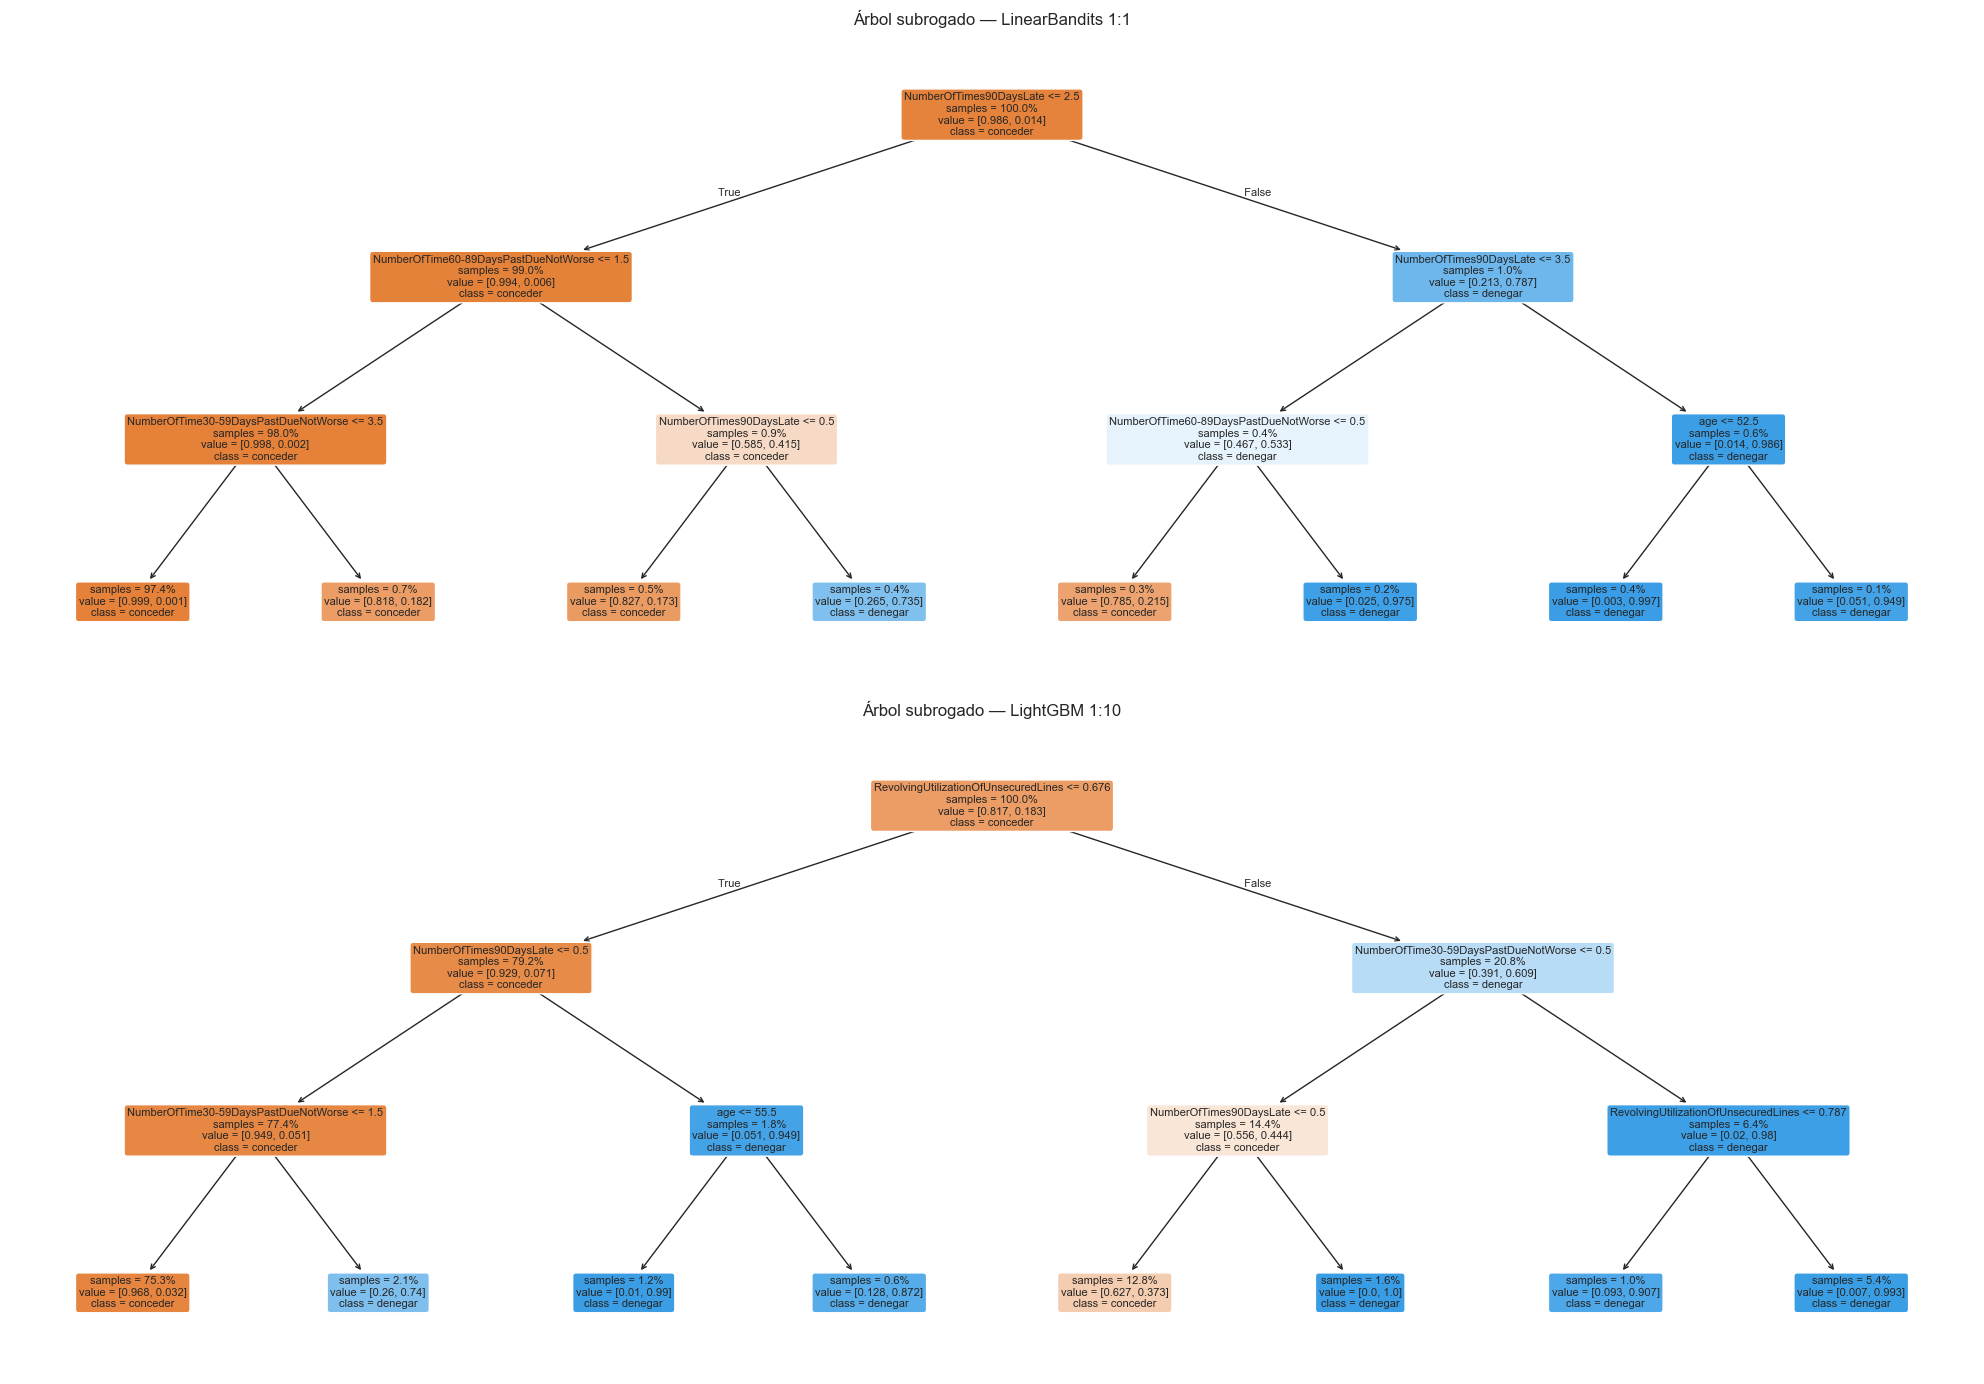

In [16]:
acciones_bandit_des = bandit_11.predict(X_band_des_scaled)
surrogado_bandit = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=100, random_state=SEED
).fit(X_band_des_limpio, acciones_bandit_des)
pred_sur_bandit = surrogado_bandit.predict(X_band_test_limpio)

p_lgb_des_modelo = modelo_lgb_110.predict_proba(X_lgb_des)[:, 1]
acciones_lgb_des = (p_lgb_des_modelo >= umbral_lgb_110).astype(int)
surrogado_lgb = Pipeline([
    ("imputación", SimpleImputer(strategy="median")),
    ("árbol", DecisionTreeClassifier(
        max_depth=3, min_samples_leaf=100, random_state=SEED
    )),
]).fit(X_lgb_des, acciones_lgb_des)
pred_sur_lgb = surrogado_lgb.predict(X_lgb_test)

fidelidad = pd.DataFrame({
    "Modelo explicado": ["LinearBandits 1:1", "LightGBM 1:10"],
    "Fidelidad test": [
        np.mean(pred_sur_bandit == pred_test_bandit_11),
        np.mean(pred_sur_lgb == pred_test_lgb_110),
    ],
    "Fidelidad equilibrada": [
        balanced_accuracy_score(pred_test_bandit_11, pred_sur_bandit),
        balanced_accuracy_score(pred_test_lgb_110, pred_sur_lgb),
    ],
    "Hojas": [
        surrogado_bandit.get_n_leaves(),
        surrogado_lgb.named_steps["árbol"].get_n_leaves(),
    ],
}).set_index("Modelo explicado")
display(fidelidad)

fig, axes = plt.subplots(2, 1, figsize=(20, 14))
plot_tree(
    surrogado_bandit, feature_names=X_band_des_limpio.columns,
    class_names=["conceder", "denegar"], filled=True, rounded=True,
    impurity=False, proportion=True, fontsize=8, ax=axes[0],
)
axes[0].set_title("Árbol subrogado — LinearBandits 1:1")
plot_tree(
    surrogado_lgb.named_steps["árbol"], feature_names=X_lgb_des.columns,
    class_names=["conceder", "denegar"], filled=True, rounded=True,
    impurity=False, proportion=True, fontsize=8, ax=axes[1],
)
axes[1].set_title("Árbol subrogado — LightGBM 1:10")
plt.tight_layout()
plt.show()

## 12. Contrafactuales restringidos

Se busca una alternativa para un caso denegado cercano a la frontera de cada modelo.
Solo se modifican variables razonablemente accionables: reducir utilización, ratio de
deuda y líneas abiertas, o documentar/aumentar ingresos. Edad, dependientes e historial
de moras quedan bloqueados. El resultado explica el modelo, no una mejora causal.
Para LightGBM se emplean el modelo y el umbral de evaluación, porque el caso procede del
test intacto. Cada modelo construye su rejilla con cuantiles de su propio desarrollo.

In [17]:
variables_accionables = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
]
cuantiles_bandit = X_des_raw[variables_accionables].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)
iqr_bandit = (
    X_des_raw[variables_accionables].quantile(0.75)
    - X_des_raw[variables_accionables].quantile(0.25)
).clip(lower=1e-6)
cuantiles_lgb = X_lgb_des_raw[variables_accionables].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)
iqr_lgb = (
    X_lgb_des_raw[variables_accionables].quantile(0.75)
    - X_lgb_des_raw[variables_accionables].quantile(0.25)
).clip(lower=1e-6)


def unicos_validos(valores):
    resultado = []
    for valor in valores:
        if pd.isna(valor):
            continue
        valor = float(valor)
        if not any(np.isclose(valor, previo) for previo in resultado):
            resultado.append(valor)
    return resultado


def rejilla_accionable(fila, cuantiles_modelo):
    uso = float(fila["RevolvingUtilizationOfUnsecuredLines"])
    deuda = float(fila["DebtRatio"])
    ingreso = fila["MonthlyIncome"]
    lineas = int(fila["NumberOfOpenCreditLinesAndLoans"])

    usos = [
        v for v in unicos_validos([uso, 0.75 * uso, 0.5 * uso, 0.25 * uso, 0])
        if v <= uso
    ]
    deudas = [
        v for v in unicos_validos([deuda, 0.75 * deuda, 0.5 * deuda, 0.25 * deuda, 0])
        if v <= deuda
    ]
    if pd.isna(ingreso):
        ingresos = unicos_validos([
            cuantiles_modelo.loc[0.50, "MonthlyIncome"],
            cuantiles_modelo.loc[0.75, "MonthlyIncome"],
            cuantiles_modelo.loc[0.90, "MonthlyIncome"],
        ])
    else:
        ingresos = [
            v for v in unicos_validos([
                ingreso, 1.25 * ingreso, 1.5 * ingreso,
                cuantiles_modelo.loc[0.75, "MonthlyIncome"],
                cuantiles_modelo.loc[0.90, "MonthlyIncome"],
                cuantiles_modelo.loc[0.95, "MonthlyIncome"],
            ]) if v >= ingreso
        ]
    lineas_posibles = sorted(set(
        max(0, int(round(v)))
        for v in [
            lineas, lineas - 1, lineas - 2, lineas - 4,
            cuantiles_modelo.loc[0.25, "NumberOfOpenCreditLinesAndLoans"], 0,
        ]
        if v <= lineas
    ), reverse=True)
    return usos, deudas, ingresos, lineas_posibles


def buscar_contrafactual(fila, predictor, cuantiles_modelo, iqr_modelo):
    candidatos = []
    for valores in itertools.product(*rejilla_accionable(fila, cuantiles_modelo)):
        candidato = fila.copy()
        for col, valor in zip(variables_accionables, valores):
            candidato[col] = valor
        candidatos.append(candidato)
    candidatos = pd.DataFrame(candidatos)[variables_originales]
    validos = np.flatnonzero(predictor(candidatos) == 0)
    if len(validos) == 0:
        return None

    distancias = []
    for pos in validos:
        candidato = candidatos.iloc[pos]
        distancia = 0.0
        for col in variables_accionables:
            antes, despues = fila[col], candidato[col]
            distancia += (
                0.5 if pd.isna(antes) else abs(despues - antes) / iqr_modelo[col]
            )
        distancias.append(distancia)
    mejor = int(validos[int(np.argmin(distancias))])
    return candidatos.iloc[mejor]


def predecir_bandit_raw(datos_raw):
    limpio = limpiador_bandit.transform(datos_raw)
    escalado = pd.DataFrame(
        scaler_bandit.transform(limpio), columns=limpio.columns
    )
    return bandit_11.predict(escalado)


def predecir_lgb_raw(datos_raw):
    p = modelo_lgb_110.predict_proba(preparar_lightgbm(datos_raw))[:, 1]
    return (p >= umbral_lgb_110).astype(int)


def encontrar_caso_con_recourse(
    posiciones, predictor, X_casos, y_casos, cuantiles_modelo, iqr_modelo
):
    for pos in posiciones[:100]:
        fila = X_casos.iloc[int(pos)]
        cf = buscar_contrafactual(
            fila, predictor, cuantiles_modelo, iqr_modelo
        )
        if cf is not None:
            return int(pos), fila, cf, int(y_casos.iloc[int(pos)])
    return None


orden_bandit = pos_bandit_denegados[
    np.argsort(score_test_bandit_11[pos_bandit_denegados])
]
orden_lgb = pos_lgb_denegados[
    np.argsort(p_test_lgb_110[pos_lgb_denegados] - umbral_lgb_110)
]
casos_cf = [
    ("LinearBandits 1:1", encontrar_caso_con_recourse(
        orden_bandit, predecir_bandit_raw, X_test_raw, y_test,
        cuantiles_bandit, iqr_bandit,
    )),
    ("LightGBM 1:10", encontrar_caso_con_recourse(
        orden_lgb, predecir_lgb_raw, X_lgb_test_raw, y_lgb_test,
        cuantiles_lgb, iqr_lgb,
    )),
]

filas_cf = []
for modelo, caso in casos_cf:
    if caso is None:
        filas_cf.append({"Modelo": modelo, "Resultado": "Sin alternativa en la rejilla"})
        continue
    pos, original, nuevo, clase_real = caso
    cambios = []
    for col in variables_accionables:
        antes, despues = original[col], nuevo[col]
        if pd.isna(antes) or not np.isclose(antes, despues):
            antes_txt = "ausente" if pd.isna(antes) else f"{antes:.3f}"
            cambios.append(
                f"{nombres_variables_es.get(col, col)}: "
                f"{antes_txt} → {despues:.3f}"
            )
    filas_cf.append({
        "Modelo": modelo,
        "Posición en test": pos,
        "Clase real": clase_real,
        "Resultado": "; ".join(cambios),
    })
display(pd.DataFrame(filas_cf).set_index("Modelo"))

,Posición en test,Clase real,Resultado
Modelo,,,
LinearBandits 1:1,18195,0,ingresos mensuales declarados: 1890.000 → 2835.000
LightGBM 1:10,2736,0,ratio de deuda: 0.315 → 0.237


## 13. Auditoría de errores por segmentos

Como comprobación crítica se compara el coste por tramo de edad. No es una auditoría
legal de equidad: solo detecta heterogeneidad que una media global podría ocultar.

In [18]:
filas_segmentos = []
for modelo, X_audit, y_audit, pred_audit, c_fn in [
    ("LinearBandits 1:1", X_test_raw, y_test, pred_test_bandit_11, 1),
    ("LightGBM 1:10", X_lgb_test_raw, y_lgb_test, pred_test_lgb_110, 10),
]:
    auditoria_modelo = X_audit.copy()
    auditoria_modelo["y_real"] = y_audit.to_numpy()
    auditoria_modelo["pred"] = pred_audit
    auditoria_modelo["Tramo de edad"] = pd.cut(
        auditoria_modelo["age"],
        bins=[0, 35, 50, 65, 80, np.inf],
        labels=["≤35", "36-50", "51-65", "66-80", ">80"],
    )
    for tramo, bloque in auditoria_modelo.groupby("Tramo de edad", observed=True):
        y_g = bloque["y_real"].to_numpy()
        pred_g = bloque["pred"].to_numpy()
        tn, fp, fn, tp = confusion_matrix(y_g, pred_g, labels=[0, 1]).ravel()
        filas_segmentos.append({
            "Modelo": modelo,
            "Tramo": tramo,
            "N": len(bloque),
            "% mora real": 100 * y_g.mean(),
            "% riesgo": 100 * pred_g.mean(),
            "FPR": fp / (fp + tn) if fp + tn else np.nan,
            "FNR": fn / (fn + tp) if fn + tp else np.nan,
            "Coste medio": coste_medio(y_g, pred_g, 1, c_fn),
        })
display(pd.DataFrame(filas_segmentos).set_index(["Modelo", "Tramo"]))

N  % mora real  % riesgo    FPR    FNR  \
Modelo            Tramo                                              
LinearBandits 1:1 ≤35    3064      10.1175    2.3172 0.0123 0.8806   
                  36-50  6897       8.4095    1.9139 0.0066 0.8448   
                  51-65  7115       5.8609    1.1244 0.0048 0.8849   
                  66-80  3242       2.5910    0.2776 0.0016 0.9524   
                  >80     682       1.9062    0.0000 0.0000 1.0000   
LightGBM 1:10     ≤35    2282       9.9474   32.1209 0.2667 0.1850   
                  36-50  5152       8.4821   25.5435 0.2070 0.2220   
                  51-65  5313       5.9289   13.2317 0.1006 0.3651   
                  66-80  2483       2.5373    6.0814 0.0496 0.5079   
                  >80     520       2.1154    5.1923 0.0413 0.4545   

                         Coste medio  
Modelo            Tramo               
LinearBandits 1:1 ≤35         0.1002  
                  36-50       0.0771  
                  51-65       0.0564  
                  66-80       0.0262  
                  >80         0.0191  
LightGBM 1:10     ≤35         0.4242  
                  36-50       0.3777  
                  51-65       0.3111  
                  66-80       0.1772  
                  >80         0.1365

## 14. Conclusión ejecutiva y limitaciones

El cierre se construye desde las salidas ejecutadas para que las cifras no queden
desincronizadas al volver a ejecutar el notebook.

In [19]:
top_bandit = ", ".join(importancia_bandit.head(4)["Variable"])
top_lgb = ", ".join(importancia_lgb_final.head(4)["Variable"])
referencias_completas = all(
    estado == "Coincidencia exacta" for estado in estados_referencia
)
texto_verificacion = (
    "Las referencias originales estaban disponibles y ambos CSV coinciden fila a fila "
    "con ellas."
    if referencias_completas
    else "La comparación con las referencias originales se ha omitido porque no estaban "
    "disponibles; esto no impide generar ni validar los entregables."
)

display(Markdown(f"""
### Resultado final

- **1:1 — LinearBandits.** Coste test **{fila_bandit['Coste medio test']:.4f}**
  frente a **{fila_bandit['Baseline conceder a todos']:.4f}** del baseline; genera
  **{int(pred_prod_11.sum()):,}** predicciones de clase 1
  (**{100 * pred_prod_11.mean():.2f} %**). Factores SHAP: **{top_bandit}**.
- **1:10 — LightGBM.** Umbral OOF de evaluación **{umbral_lgb_110:.4f}** y
  umbral OOF de producción **{umbral_lgb_110_produccion:.4f}**; coste test
  **{fila_lgb['Coste medio test']:.4f}** frente a
  **{fila_lgb['Baseline conceder a todos']:.4f}**; genera
  **{int(pred_prod_110.sum()):,}** predicciones de clase 1
  (**{100 * pred_prod_110.mean():.2f} %**). Factores SHAP global del modelo final de
  producción: **{top_lgb}**. Las explicaciones locales, la permutación, el subrogado
  y los contrafactuales auditan el modelo de evaluación sobre su test intacto.
- Los entregables cs_produccion1.csv y cs_produccion2.csv tienen 45.000 filas,
  estructura original y objetivo binario completo. {texto_verificacion}

### Limitaciones

1. Las etiquetas de producción están ocultas; su coste real solo lo conoce el evaluador.
2. SHAP, los subrogados y los contrafactuales explican modelos, no relaciones causales.
3. Los datos históricos pueden contener sesgos, códigos especiales y errores de medición.
4. Los contrafactuales son escenarios restringidos, no promesas de aprobación.
5. Una decisión sensible requiere supervisión, revisión humana y corrección de datos.
"""))


### Resultado final

- **1:1 — LinearBandits.** Coste test **0.0637**
  frente a **0.0669** del baseline; genera
  **658** predicciones de clase 1
  (**1.46 %**). Factores SHAP: **NumberOfTimes90DaysLate, NumberOfTime30-59DaysPastDueNotWorse, RevolvingUtilizationOfUnsecuredLines, NumberOfTime60-89DaysPastDueNotWorse**.
- **1:10 — LightGBM.** Umbral OOF de evaluación **0.0907** y
  umbral OOF de producción **0.0815**; coste test
  **0.3224** frente a
  **0.6686**; genera
  **9,157** predicciones de clase 1
  (**20.35 %**). Factores SHAP global del modelo final de
  producción: **RevolvingUtilizationOfUnsecuredLines, NumberOfTimes90DaysLate, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse**. Las explicaciones locales, la permutación, el subrogado
  y los contrafactuales auditan el modelo de evaluación sobre su test intacto.
- Los entregables cs_produccion1.csv y cs_produccion2.csv tienen 45.000 filas,
  estructura original y objetivo binario completo. Las referencias originales estaban disponibles y ambos CSV coinciden fila a fila con ellas.

### Limitaciones

1. Las etiquetas de producción están ocultas; su coste real solo lo conoce el evaluador.
2. SHAP, los subrogados y los contrafactuales explican modelos, no relaciones causales.
3. Los datos históricos pueden contener sesgos, códigos especiales y errores de medición.
4. Los contrafactuales son escenarios restringidos, no promesas de aprobación.
5. Una decisión sensible requiere supervisión, revisión humana y corrección de datos.
